In [ ]:
import io
from PIL import Image
from collections import Counter
from transformers import AutoImageProcessor, ViTForImageClassification
from datasets import Dataset, DatasetDict, load_dataset
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch
import accelerate

In [ ]:
ds = load_dataset("enterprise-explorers/oxford-pets")

In [ ]:
ds

DatasetDict({
    train: Dataset({
        features: ['path', 'label', 'dog', 'image'],
        num_rows: 7390
    })
})

In [ ]:
label_counts = Counter(ds["train"]["label"])
for label_id, count in label_counts.items():
    print(f"{label_id}: {count}")

Siamese: 200
Birman: 200
shiba inu: 200
staffordshire bull terrier: 191
basset hound: 200
Bombay: 200
japanese chin: 200
chihuahua: 200
german shorthaired: 200
pomeranian: 200
beagle: 200
english cocker spaniel: 200
american pit bull terrier: 200
Ragdoll: 200
Persian: 200
Egyptian Mau: 200
miniature pinscher: 200
Sphynx: 200
Maine Coon: 200
keeshond: 200
yorkshire terrier: 200
havanese: 200
leonberger: 200
wheaten terrier: 200
american bulldog: 200
english setter: 200
boxer: 200
newfoundland: 200
Bengal: 200
samoyed: 200
British Shorthair: 200
great pyrenees: 200
Abyssinian: 200
pug: 200
saint bernard: 200
Russian Blue: 200
scottish terrier: 199


In [ ]:
ds = ds.remove_columns(["dog", "path"])
ds

DatasetDict({
    train: Dataset({
        features: ['label', 'image'],
        num_rows: 7390
    })
})

In [ ]:
tt_ds = ds['train'].train_test_split(test_size=0.2)
teval_ds = tt_ds['test'].train_test_split(test_size=0.5)

ds = DatasetDict({
    'train': tt_ds['train'],
    'validation': teval_ds['train'],
    'test': teval_ds['test']
})

ds

DatasetDict({
    train: Dataset({
        features: ['label', 'image'],
        num_rows: 5912
    })
    validation: Dataset({
        features: ['label', 'image'],
        num_rows: 739
    })
    test: Dataset({
        features: ['label', 'image'],
        num_rows: 739
    })
})

In [ ]:
labels = ds['train'].unique('label')
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}

In [ ]:
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels = len(labels),
    id2label = id2label,
    label2id = label2id,
    ignore_mismatched_sizes = True
)
image_processor = processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224', use_fast=True)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([37]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([37, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def pre_processing(input):
  input['pixel_values'] = processor(input['image'].convert("RGB"), return_tensors="pt").pixel_values.squeeze()
  input["label"] = label2id[input["label"]]
  return input

ds = ds.map(pre_processing)

In [ ]:
def collate_fn(examples):
    pixel_values = torch.stack([torch.tensor(example["pixel_values"]) for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
training_args = TrainingArguments(
    output_dir="./resultados",
    run_name="pet_classification",
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    learning_rate=2e-5,
    num_train_epochs=30,
    eval_steps=500,
    logging_steps=500,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    warmup_ratio=0.1,
    greater_is_better=True,
)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted', zero_division=0),
        'precision': precision_score(labels, predictions, average='weighted', zero_division=0),
        'recall': recall_score(labels, predictions, average='weighted', zero_division=0)
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=ds['train'],
    eval_dataset=ds['validation'],
    processing_class=image_processor,
    data_collator = collate_fn,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,3.072270,0.316644,0.290221,0.303365,0.316644
2,No log,1.143793,0.884980,0.884698,0.892436,0.884980
3,2.233400,0.360398,0.922869,0.923005,0.926642,0.922869
4,2.233400,0.241307,0.935047,0.934924,0.938336,0.935047
5,2.233400,0.229682,0.932341,0.931531,0.934858,0.932341
6,0.110200,0.216300,0.939107,0.938995,0.941726,0.939107
7,0.110200,0.217853,0.936401,0.935921,0.939455,0.936401
8,0.110200,0.216356,0.937754,0.937309,0.940444,0.937754
9,0.007800,0.216906,0.936401,0.935930,0.939158,0.936401
10,0.007800,0.221421,0.935047,0.934542,0.938170,0.935047


TrainOutput(global_step=5550, training_loss=0.21268115431540185, metrics={'train_runtime': 12680.5258, 'train_samples_per_second': 13.987, 'train_steps_per_second': 0.438, 'total_flos': 1.3748290680909496e+19, 'train_loss': 0.21268115431540185, 'epoch': 30.0})

In [ ]:
model.save_pretrained("./pet_model")

In [ ]:
predictions = trainer.predict(ds["test"])
predicted_labels = predictions.predictions.argmax(axis=-1)
print(classification_report(ds["test"]["label"], predicted_labels, target_names=label2id))

                            precision    recall  f1-score   support

                    Birman       0.86      0.86      0.86        21
            great pyrenees       1.00      1.00      1.00        15
                Maine Coon       0.95      0.95      0.95        20
         British Shorthair       0.95      0.86      0.90        21
          scottish terrier       0.91      1.00      0.95        20
                   Persian       1.00      0.90      0.95        20
                leonberger       1.00      0.95      0.97        19
                       pug       1.00      1.00      1.00        21
                    Bombay       1.00      1.00      1.00        19
                   Ragdoll       0.87      0.83      0.85        24
              newfoundland       1.00      1.00      1.00        30
 american pit bull terrier       0.75      0.84      0.79        25
            english setter       0.93      1.00      0.96        13
                  havanese       1.00      0.92

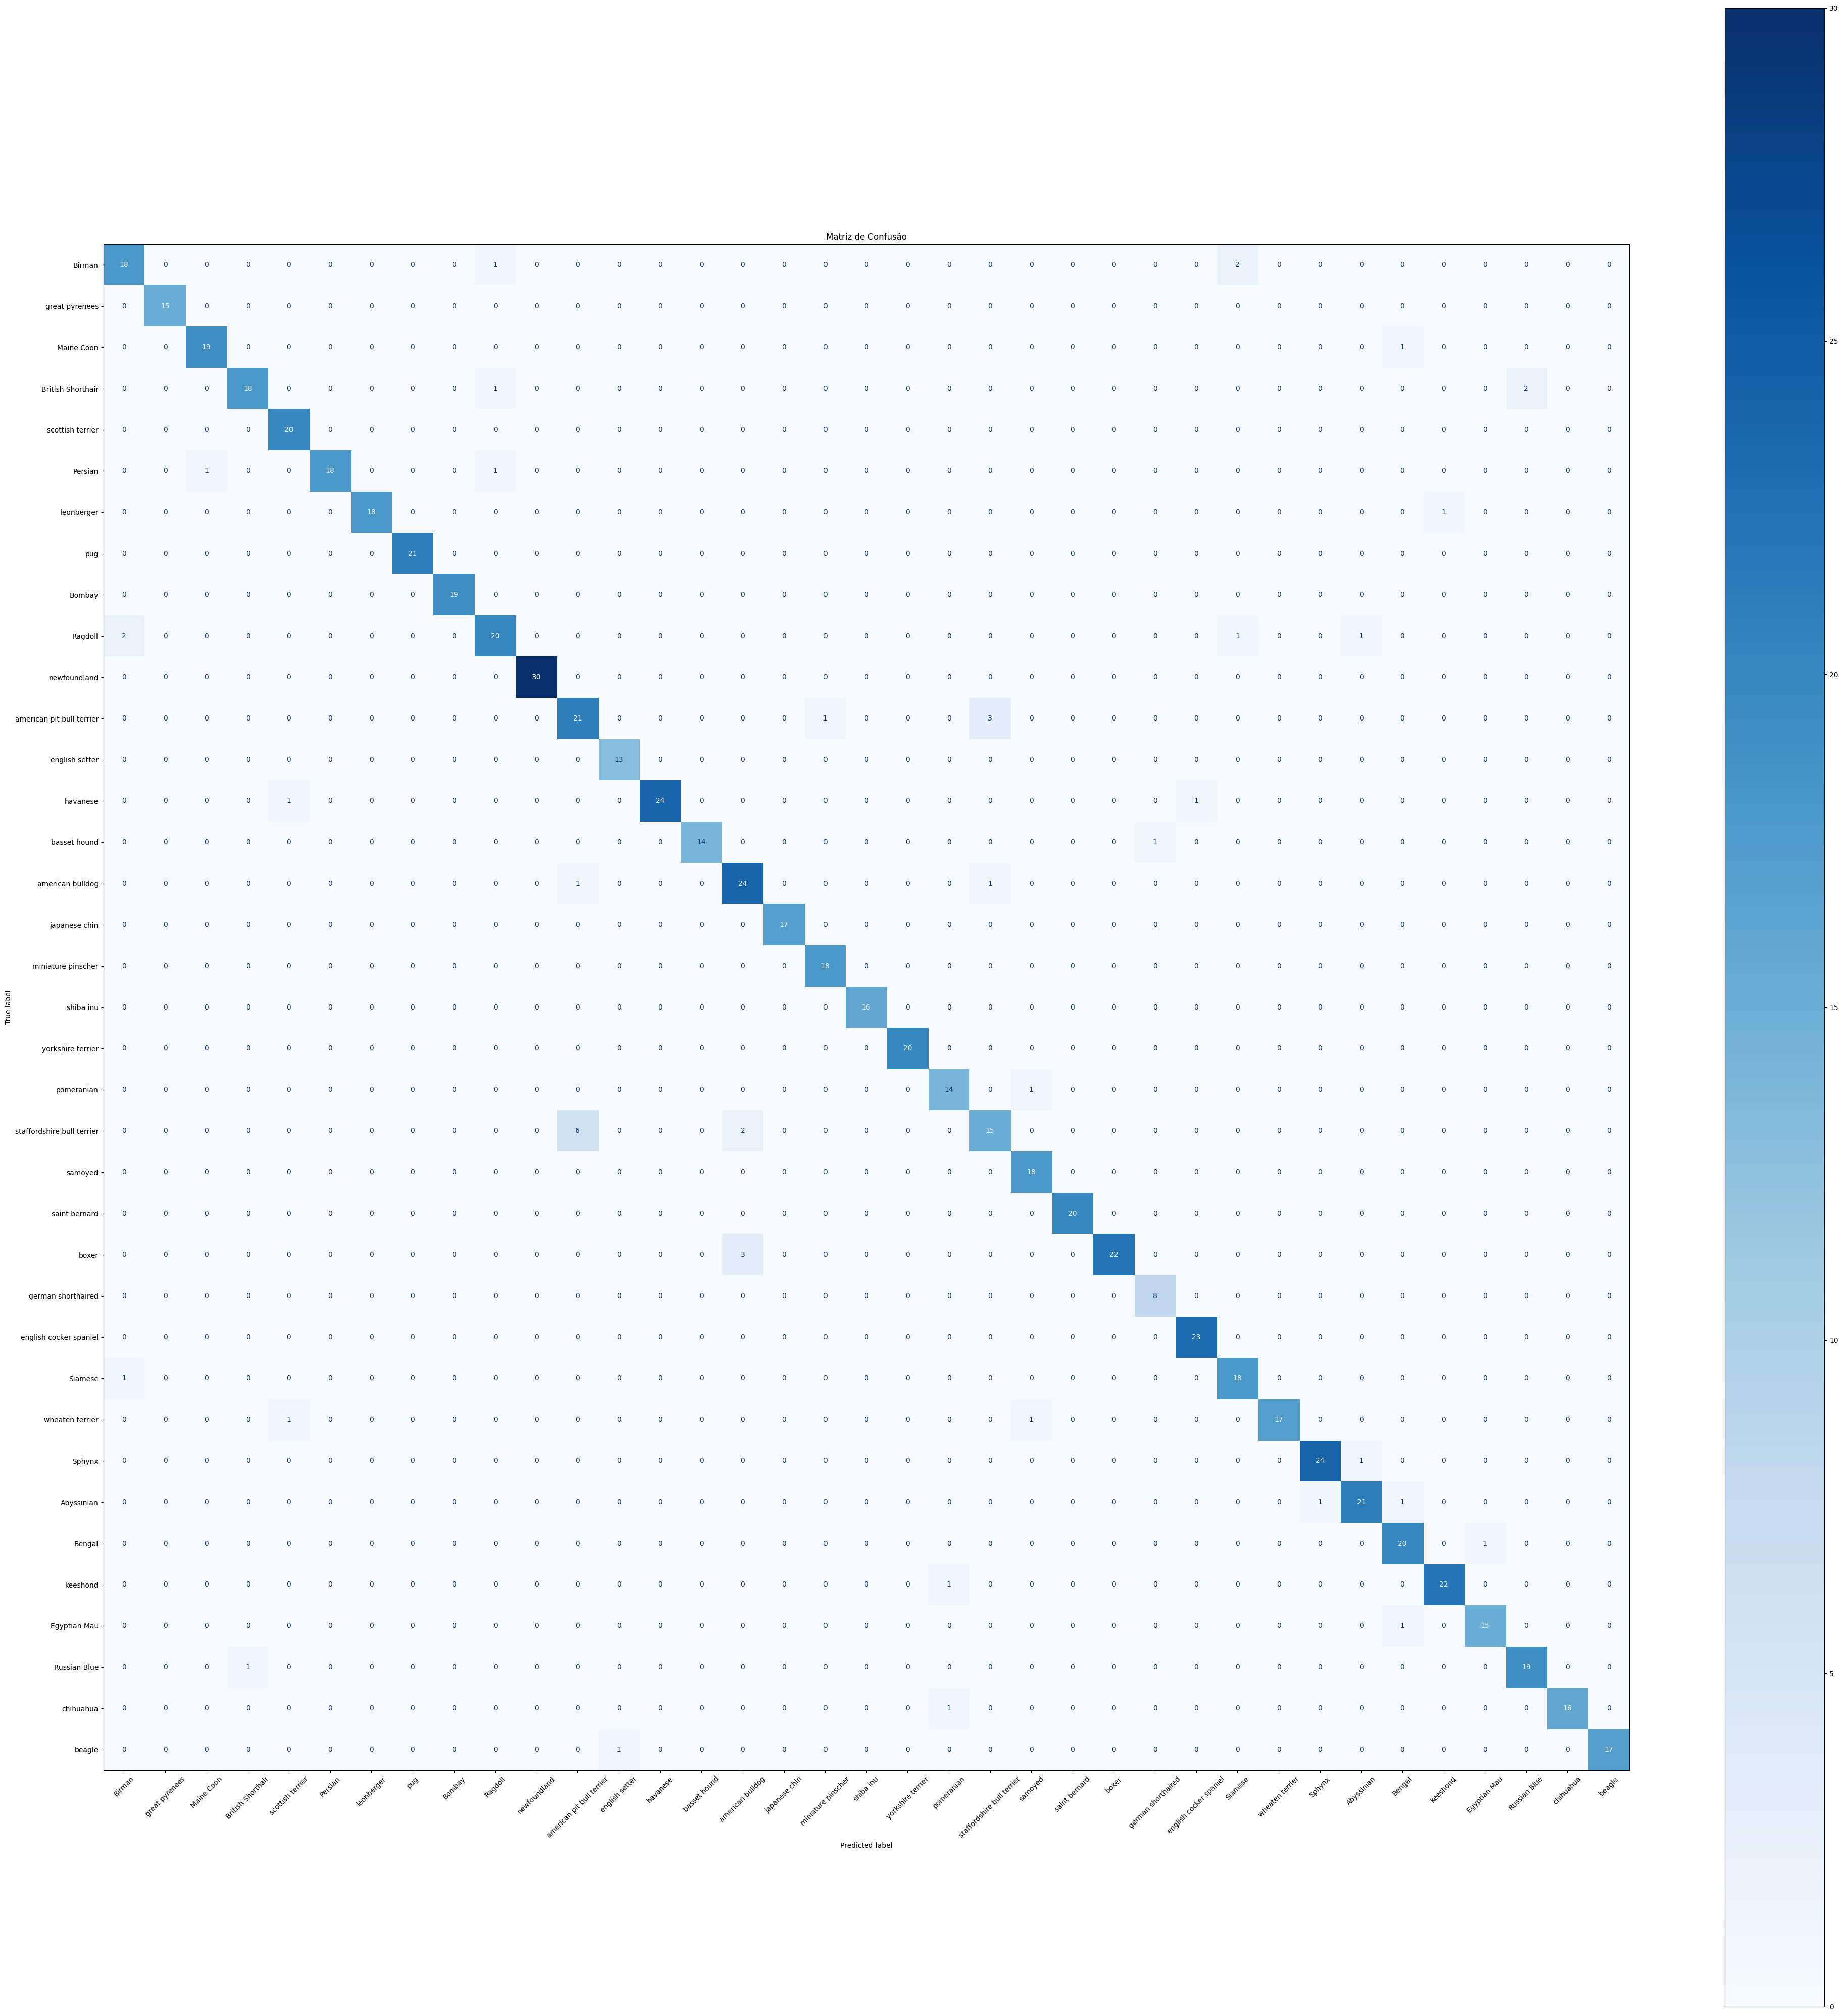

In [ ]:
true_labels = ds["test"]["label"]
predicted_labels = predictions.predictions.argmax(axis=-1)

cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label2id)

fig, ax = plt.subplots(figsize=(40, 40))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)

plt.title("Matriz de Confusão")
plt.tight_layout()
plt.show()

In [ ]:
from transformers import pipeline

pipe = pipeline("image-classification", model="Shedinja/vit-pet-classification")
pipe("basset-hound.webp")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

Device set to use cuda:0


[{'label': 'basset hound', 'score': 0.9930379986763},
 {'label': 'beagle', 'score': 0.0012629841221496463},
 {'label': 'german shorthaired', 'score': 0.0007686639437451959},
 {'label': 'english setter', 'score': 0.0004256739921402186},
 {'label': 'english cocker spaniel', 'score': 0.00040607270784676075}]

In [ ]:
pipe("shiba-inu.jpeg")

[{'label': 'shiba inu', 'score': 0.9947758913040161},
 {'label': 'samoyed', 'score': 0.0005251815309748054},
 {'label': 'pug', 'score': 0.00029217905830591917},
 {'label': 'keeshond', 'score': 0.0002734130248427391},
 {'label': 'Abyssinian', 'score': 0.00025614252081140876}]

In [ ]:
pipe("abyssinian.jpg")

[{'label': 'Abyssinian', 'score': 0.9904680848121643},
 {'label': 'Bengal', 'score': 0.0015415661036968231},
 {'label': 'shiba inu', 'score': 0.0006480859010480344},
 {'label': 'Maine Coon', 'score': 0.0006305769202299416},
 {'label': 'basset hound', 'score': 0.0005058171227574348}]

In [ ]:
pipe("egyptian-mau.jpeg")

[{'label': 'Egyptian Mau', 'score': 0.9948786497116089},
 {'label': 'Bengal', 'score': 0.0015137434238567948},
 {'label': 'english setter', 'score': 0.0002678553864825517},
 {'label': 'japanese chin', 'score': 0.00024010198831092566},
 {'label': 'chihuahua', 'score': 0.0002149736974388361}]